HIERARCHICAL CLUSTERING – Mall Customer Segmentation
======================================================
Dataset : Mall_Customers.csv (200 rows × 5 columns)
Features used: Annual Income (k$)  &  Spending Score (1-100)
Best method   : Ward Linkage  |  Optimal clusters : 5

#STEP 1: Import Libraries

### 📦 Step 1 — Import Libraries

This cell imports all the external Python libraries needed for the entire analysis pipeline:

| Library | Purpose |
|---|---|
| `pandas` | Loads and manipulates the dataset as a DataFrame — enables filtering, grouping, and summary statistics |
| `numpy` | Provides numerical array operations used internally by scikit-learn and scipy |
| `matplotlib.pyplot` | Core plotting engine for all charts: histograms, scatter plots, boxplots, and cluster visualizations |
| `seaborn` | High-level statistical visualization built on top of matplotlib — used here for the correlation heatmap |
| `scipy.cluster.hierarchy` | Core hierarchical clustering tools: `linkage` builds the cluster tree, `dendrogram` visualizes it, `fcluster` cuts it into flat labels |
| `sklearn.preprocessing.StandardScaler` | Standardizes features to zero mean and unit variance before clustering |
| `sklearn.metrics.silhouette_score` | Measures how well-separated the clusters are — used to find the optimal number of clusters |

> 💡 All imports are placed at the top to make dependencies visible and avoid runtime errors mid-notebook.


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

#STEP 2 – LOAD Dataset

### 📂 Step 2 — Load Dataset

This cell reads the `Mall_Customers.csv` file from Google Drive into a pandas DataFrame called `df`.

- `pd.read_csv(path)` parses the CSV file and automatically infers column data types
- The path points to a Google Colab–mounted Drive location — **update this path** if running locally
- After loading, `df` holds all 200 customer records across 5 columns: `CustomerID`, `Gender`, `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`

> 💡 For local execution, replace the path with: `pd.read_csv('Mall_Customers.csv')`


In [36]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Hierarchical Clustering Assignment Mall Customer Data/Mall_Customers.csv')

#Step 3 Data Understanding

### 🔍 Step 3 — Data Understanding

The following cells perform an initial inspection of the dataset to understand its structure, content, and quality before any analysis begins.

---

#### `df.head()` — Preview the First 5 Rows
Returns the first 5 rows of the DataFrame. This gives an immediate sense of what the data looks like — column names, sample values, and data formatting.


In [37]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### `df.describe()` — Statistical Summary

Computes descriptive statistics for all **numeric columns**: `CustomerID`, `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`.

| Statistic | Meaning |
|---|---|
| `count` | Number of non-null entries |
| `mean` | Average value |
| `std` | Standard deviation — spread of values |
| `min / max` | Extreme values |
| `25% / 50% / 75%` | Quartile distribution |

> 💡 A high standard deviation in Income or Spending Score signals strong variability — exactly what makes clustering meaningful.


In [38]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#### `df.info()` — Data Types and Non-Null Counts

Prints a concise summary of the DataFrame: column names, number of non-null values, and the dtype of each column.

- Confirms no missing values (all 200 rows non-null across all 5 columns)
- Shows `Gender` is an object (string), while the other columns are integers
- Helps identify any unexpected data types that would need conversion


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


#### `df.shape` — Dataset Dimensions

Returns a tuple `(rows, columns)` — confirms the dataset has **200 rows and 5 columns**.

This is a quick sanity check to ensure the full file loaded correctly.


In [40]:
df.shape

(200, 5)

#### `len('column')` and `len('rows')` — String Length (Note)

> ⚠️ These two `print(len(...))` statements measure the **character length of the string literals** `'column'` (6) and `'rows'` (4), **not** the actual number of columns or rows in the dataset.
>
> They are likely leftover placeholder cells from early development. The correct approaches would be:
> ```python
> print(len(df.columns))  # → 5 columns
> print(len(df))          # → 200 rows
> ```


In [41]:
print(len('column'))

6


In [42]:
print(len('rows'))

4


#### `list(df.columns)` — Column Names

Prints the list of all column names in the DataFrame:
`['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']`

Useful for confirming exact column names before referencing them in code (especially for columns with spaces or special characters like `k$`).


In [43]:
print(list(df.columns))

['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


# checking for null values

#### `df.isnull().sum()` — Null Value Check

Counts the number of missing (`NaN`) values in each column.

- Returns `0` for all 5 columns — the dataset is **complete with no missing values**
- This means no imputation or data cleaning is required before analysis
- A critical quality gate before any EDA or modeling

> 💡 If nulls were found, strategies would include: dropping rows, filling with mean/median, or using domain knowledge to impute values.


In [44]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


# Step 4 - Exploratory Data Analysis

distribution of each column

### 📊 Step 4 — Exploratory Data Analysis (EDA)

EDA helps us visually understand the data distribution, identify outliers, and discover relationships between features — all of which inform how and why we cluster.

---

#### Histogram — Age Distribution

Creates a histogram for the `Age` column using 20 bins.

- **`plt.figure(figsize=(14,4))`** — Sets a wide canvas (14×4 inches) to hold all three histograms side-by-side
- **`plt.subplot(1, 3, 1)`** — Positions this chart as the first of three panels in a single row
- **`bins=20`** — Divides the age range into 20 equal intervals for granular distribution view
- **`color='steelblue'`, `edgecolor='black'`** — Applies a clean color scheme with visible bar boundaries

> 📌 Insight: The age distribution is relatively spread across 18–70, with a concentration in the 25–45 range — typical of active mall shoppers.


Text(0, 0.5, 'Count')

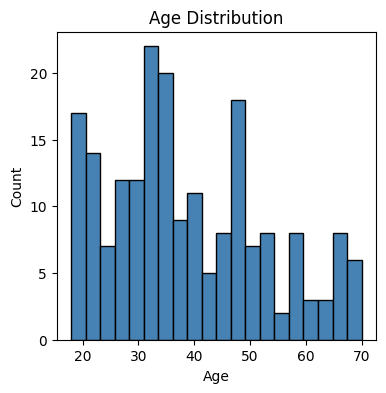

In [45]:
plt.figure(figsize=(14,4))
plt.subplot(1, 3, 1)
plt.hist(df['Age'], bins=20, color='steelblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

#### Histogram — Annual Income Distribution

Plots the distribution of `Annual Income (k$)` as the second subplot.

- Uses `color='salmon'` for visual distinction from the Age chart
- The distribution reveals how customer incomes are spread — whether skewed toward lower or higher earners
- Helps identify income brackets that may form natural customer segments

> 📌 Insight: Income shows a roughly uniform or slightly right-skewed distribution across $15k–$137k.


Text(0.5, 0, 'Annual Income (k$)')

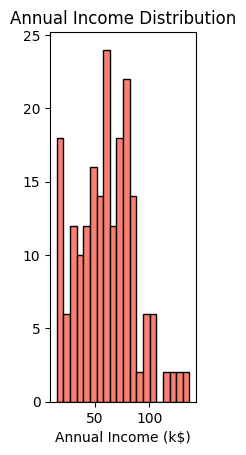

In [46]:
plt.subplot(1, 3, 2)
plt.hist(df['Annual Income (k$)'], bins=20, color='salmon', edgecolor='black')
plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (k$)')

#### Histogram — Spending Score Distribution

Plots the `Spending Score (1-100)` distribution as the third subplot.

- `color='mediumseagreen'` continues the distinct color coding
- The spending score is an engineered feature (assigned by the mall) — its distribution shows how shoppers are rated across the full 1–100 range

> 📌 Insight: Spending scores appear approximately uniform, suggesting no single spending behavior dominates.


Text(0.5, 0, 'Spending Score')

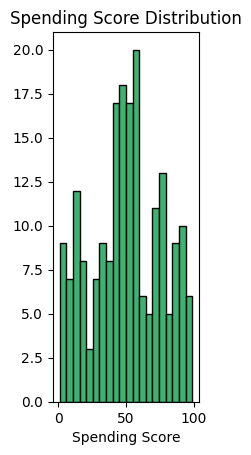

In [47]:
plt.subplot(1, 3, 3)
plt.hist(df['Spending Score (1-100)'], bins=20, color='mediumseagreen', edgecolor='black')
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')

#### Save & Show All Three Histograms

- **`plt.tight_layout()`** — Automatically adjusts subplot spacing to prevent overlapping titles and labels
- **`plt.savefig('eda_distributions.png', dpi=120)`** — Saves the combined figure to disk at 120 DPI (good quality for reports)
- **`plt.show()`** — Renders and displays the figure inline in the notebook


In [48]:
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=120)
plt.show()

<Figure size 640x480 with 0 Axes>

# scatter plot - income vs spending score

#### Scatter Plot — Annual Income vs. Spending Score

Creates a scatter plot with `Annual Income (k$)` on the X-axis and `Spending Score (1-100)` on the Y-axis.

- **This is the single most important EDA chart** — it visually reveals approximately 5 distinct natural clusters before any algorithm is applied
- **`alpha=0.6`** — Adds slight transparency to overlapping points for better density visibility
- **`color='steelblue'`** — Uniform color at this stage (before cluster labels are assigned)
- Saved as `eda_scatter.png` for documentation

> 📌 Insight: Five distinct groups are clearly visible — low income/low spend, low income/high spend, medium income/medium spend, high income/low spend, and high income/high spend. This human observation validates choosing k=5 before running the algorithm.


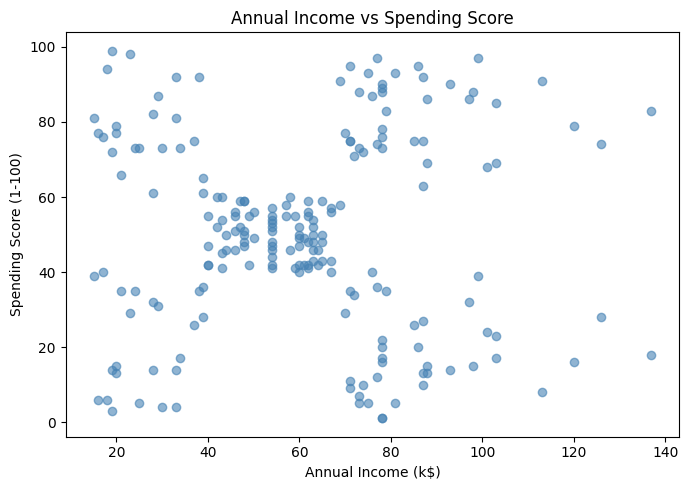

Saved: eda_scatter.png


In [49]:
plt.figure(figsize=(7, 5))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], color='steelblue', alpha=0.6)
plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.tight_layout()
plt.savefig('eda_scatter.png', dpi=120)
plt.show()
print("Saved: eda_scatter.png")

# boxplots to see spread

#### Boxplots — Outlier Detection

Creates three side-by-side boxplots for `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`.

Each boxplot shows:
| Component | Meaning |
|---|---|
| Box center line | Median (50th percentile) |
| Box edges | Q1 (25th) and Q3 (75th) percentile |
| Whiskers | Range within 1.5×IQR |
| Points beyond whiskers | Outliers |

- **`plt.subplot(1, 3, 1/2/3)`** — Arranges all three in a single row for easy comparison
- Saved as `eda_boxplots.png`

> 📌 Insight: Income shows a few mild high-end outliers. Spending Score and Age appear clean. No extreme outliers that would distort clustering.


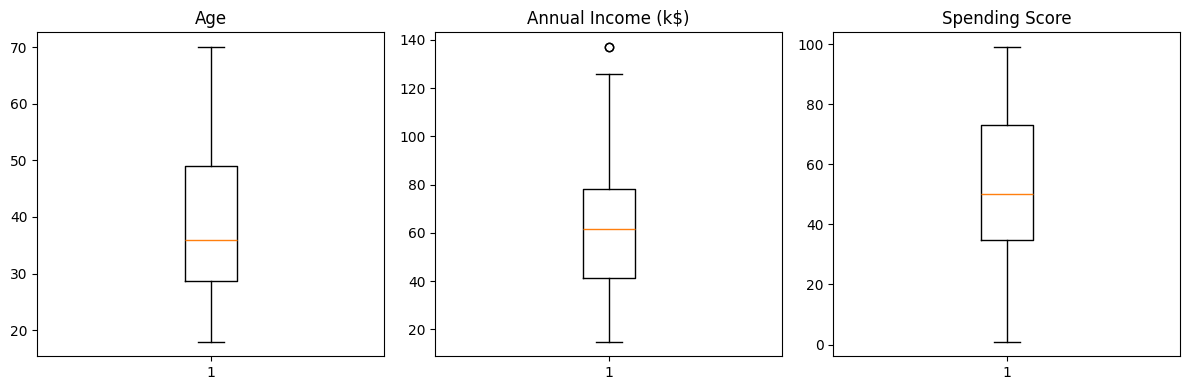

In [50]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.boxplot(df['Age'])
plt.title('Age')

plt.subplot(1, 3, 2)
plt.boxplot(df['Annual Income (k$)'])
plt.title('Annual Income (k$)')

plt.subplot(1, 3, 3)
plt.boxplot(df['Spending Score (1-100)'])
plt.title('Spending Score')

plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=120)
plt.show()

# gender count

#### Bar Chart — Gender Distribution

Counts the number of Male vs. Female customers and plots them as a bar chart.

- **`df['Gender'].value_counts()`** — Returns counts of each unique gender value
- **`.plot(kind='bar', color=['coral', 'steelblue'])`** — Renders as a bar chart with distinct colors per gender
- **`plt.xticks(rotation=0)`** — Keeps labels horizontal for readability
- Saved as `eda_gender.png`

> 📌 Insight: Female customers slightly outnumber male customers (~112 vs. ~88). This demographic information can influence cluster-specific marketing strategies.


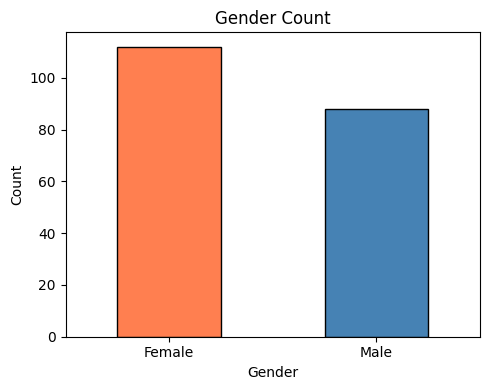

In [51]:
plt.figure(figsize=(5, 4))
df['Gender'].value_counts().plot(kind='bar', color=['coral', 'steelblue'], edgecolor='black')
plt.title('Gender Count')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('eda_gender.png', dpi=120)
plt.show()

# correlation heatmap

#### Correlation Heatmap

Computes and visualizes the **Pearson correlation matrix** between `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`.

- **`df[...].corr()`** — Computes pairwise correlations ranging from -1 (perfect negative) to +1 (perfect positive)
- **`sns.heatmap(corr, annot=True, cmap='coolwarm')`** — Renders the matrix as a color-coded grid with numerical annotations
- **`cmap='coolwarm'`** — Blue for negative, red for positive correlations; white near zero
- Saved as `eda_heatmap.png`

> 📌 Insight: Age has a mild negative correlation with Spending Score (younger customers tend to spend more). Annual Income and Spending Score show near-zero correlation — confirming they are independently varying, which makes their combination ideal for clustering.


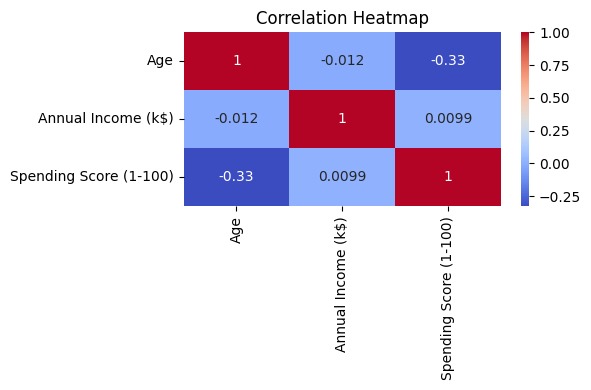

In [52]:
plt.figure(figsize=(6, 4))
corr = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('eda_heatmap.png', dpi=120)
plt.show()

#Step 5 - Feature Selection and Scaling

# using Annual Income and Spending Score for clustering
# because these two show the clearest pattern from the scatter plot

### ⚙️ Step 5 — Feature Selection and Standard Scaling

#### Why These Two Features?

`Annual Income (k$)` and `Spending Score (1-100)` were selected because:
1. The EDA scatter plot clearly showed 5 visually separable clusters in this 2D space
2. Age showed weaker discriminative power
3. `CustomerID` is an identifier and carries no behavioral meaning

```python
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
```
Extracts the two features as a raw NumPy array (shape: 200×2) suitable for sklearn and scipy.

#### Standard Scaling

```python
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
```

- **`fit_transform(X)`** — Learns the mean and standard deviation from `X`, then transforms it so each feature has mean ≈ 0 and std ≈ 1
- **Why scale?** Hierarchical clustering uses distance metrics. Without scaling, Annual Income (range: 15–137) would dominate over Spending Score (range: 1–100) purely due to magnitude
- The printed verification confirms: `Mean ≈ [0, 0]` and `Std ≈ [1, 1]`


In [53]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# standardizing the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling done.")
print("Mean after scaling:", X_scaled.mean(axis=0).round(3))
print("Std after scaling:", X_scaled.std(axis=0).round(3))

Feature scaling done.
Mean after scaling: [-0. -0.]
Std after scaling: [1. 1.]


#Step 6 - Dendrogram to find the best number of clusters

### 🌲 Step 6 — Dendrogram Analysis

A **dendrogram** is a tree diagram that shows the order in which clusters were merged during hierarchical clustering. The height of each merge indicates the distance at which two groups were joined. We look for the largest vertical gap — that gap tells us where to "cut" the tree to get the optimal clusters.

---

#### Dendrogram — Ward Linkage

```python
Z = linkage(X_scaled, method='ward')
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90)
```

- **`linkage(X_scaled, method='ward')`** — Builds the hierarchical cluster tree using Ward's method. Ward minimizes the total within-cluster variance at each merge — producing compact, well-balanced clusters
- **`truncate_mode='lastp', p=30`** — Shows only the last 30 merges (top of the tree) to keep the plot readable for 200 samples
- **`leaf_rotation=90`** — Rotates x-axis labels vertically for legibility

> 📌 Result: The Ward dendrogram shows a clear cut at 5 clusters — a large vertical gap appears just before the 5th merge, confirming k=5 is the natural split.


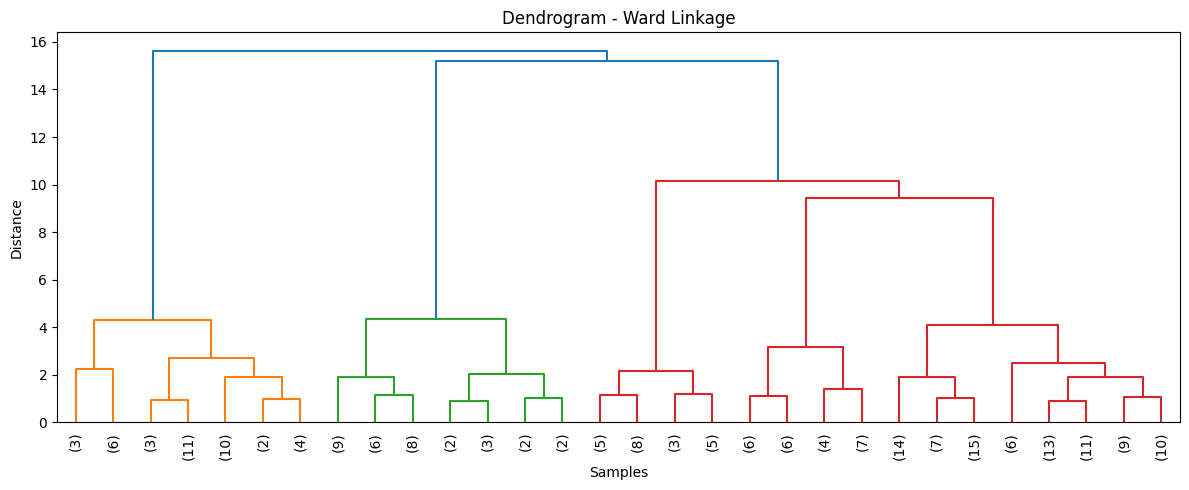

In [54]:
# trying ward linkage first
plt.figure(figsize=(12, 5))
Z = linkage(X_scaled, method='ward')
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.title('Dendrogram - Ward Linkage')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

#### Dendrogram — Complete Linkage

```python
Z2 = linkage(X_scaled, method='complete')
```

Complete linkage defines the distance between two clusters as the **maximum** pairwise distance between all points in the two clusters.

- Tends to form more compact, similarly-sized clusters
- More sensitive to outliers than Ward linkage
- Used here for comparison to validate the Ward result

> 📌 Result: Complete linkage also suggests 5 clusters, though the gaps are less pronounced than Ward.


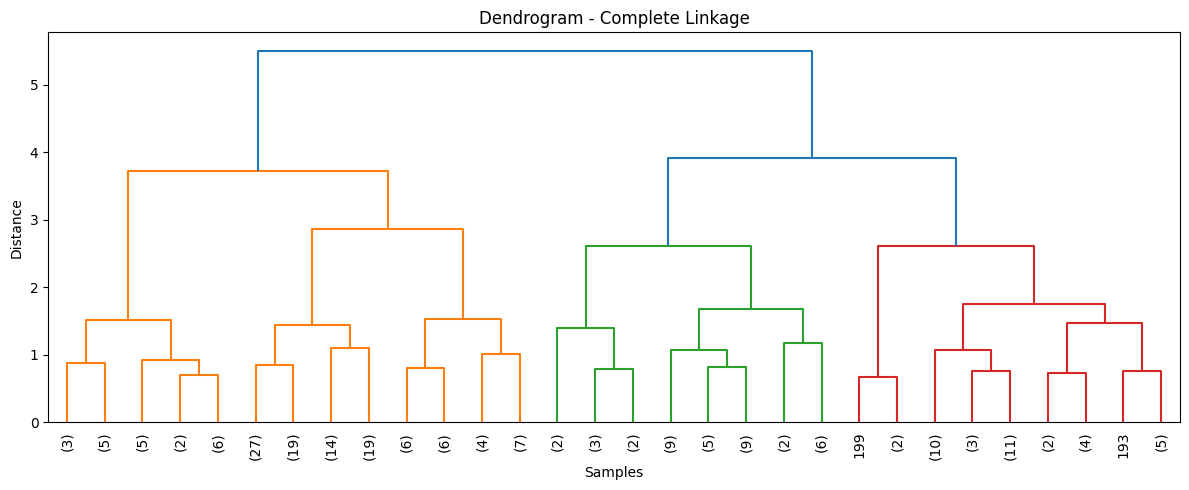

In [55]:
# complete linkage
plt.figure(figsize=(12, 5))
Z2 = linkage(X_scaled, method='complete')
dendrogram(Z2, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.title('Dendrogram - Complete Linkage')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

#### Dendrogram — Average Linkage

```python
Z3 = linkage(X_scaled, method='average')
```

Average linkage defines inter-cluster distance as the **mean** of all pairwise distances between the two clusters.

- A middle ground between single and complete linkage
- Less sensitive to outliers than complete linkage
- Compared here to cross-validate the optimal k

> 📌 Result: Average linkage supports 5 clusters as well. Across all three methods, k=5 is consistently suggested.


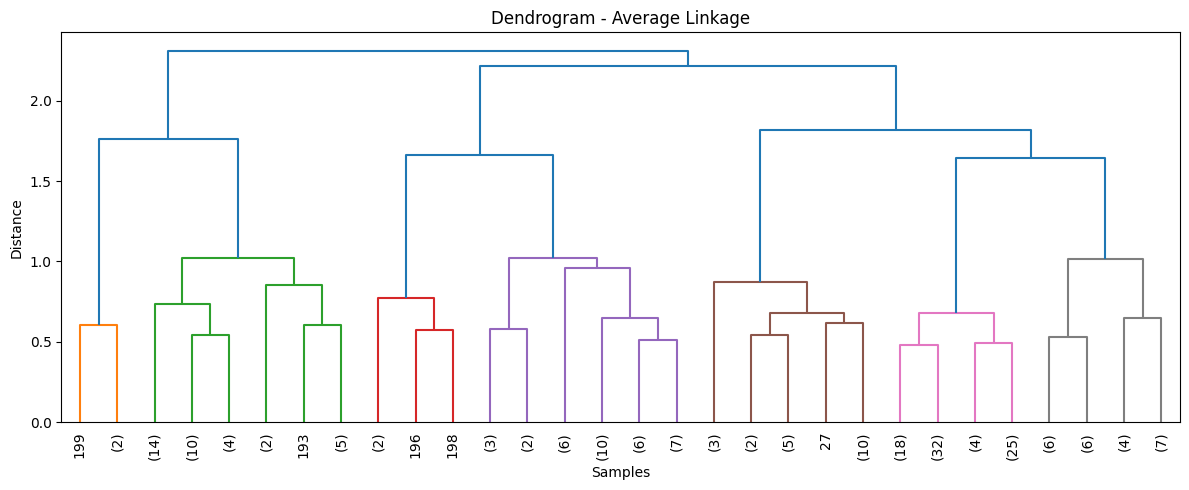

In [56]:
# average linkage
plt.figure(figsize=(12, 5))
Z3 = linkage(X_scaled, method='average')
dendrogram(Z3, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.title('Dendrogram - Average Linkage')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# Step 7 - Choosing the best number of clusters using Silhouette Score

### 📐 Step 7 — Silhouette Score Validation

#### What is a Silhouette Score?

The **Silhouette Score** quantifies how well each point fits its assigned cluster vs. neighboring clusters:
- Score of **+1**: The point is perfectly within its cluster and far from others
- Score of **0**: The point is on the boundary between clusters
- Score of **-1**: The point may have been assigned to the wrong cluster

A higher average silhouette score = better-defined clusters.

#### Computing Scores for k = 2 to 8

```python
for k in range(2, 9):
    labels = fcluster(Z, k, criterion='maxclust')
    score = silhouette_score(X_scaled, labels)
    print(f"  k={k}  =>  silhouette score = {score:.4f}")
```

- **`fcluster(Z, k, criterion='maxclust')`** — Cuts the Ward linkage tree `Z` to produce exactly `k` flat cluster labels
- **`silhouette_score(X_scaled, labels)`** — Computes the mean silhouette coefficient across all 200 samples
- The loop prints a comparison table for k = 2 through 8


In [57]:
for k in range(2, 9):
    labels = fcluster(Z, k, criterion='maxclust')
    score = silhouette_score(X_scaled, labels)
    print(f"  k={k}  =>  silhouette score = {score:.4f}")

  k=2  =>  silhouette score = 0.3842
  k=3  =>  silhouette score = 0.4610
  k=4  =>  silhouette score = 0.4926
  k=5  =>  silhouette score = 0.5538
  k=6  =>  silhouette score = 0.5387
  k=7  =>  silhouette score = 0.5198
  k=8  =>  silhouette score = 0.4309


 from the scores, k=5 gives the best result

 also the dendrogram clearly shows 5 clusters

#### Building the Scores List for Plotting

```python
scores_list = []
k_values = list(range(2, 9))
for k in k_values:
    labels = fcluster(Z, k, criterion='maxclust')
    scores_list.append(silhouette_score(X_scaled, labels))
```

Repeats the silhouette computation and stores results in a list `scores_list` — this separates data collection from plotting, keeping the visualization code clean.


In [58]:
# plotting silhouette scores
scores_list = []
k_values = list(range(2, 9))
for k in k_values:
    labels = fcluster(Z, k, criterion='maxclust')
    scores_list.append(silhouette_score(X_scaled, labels))

#### Silhouette Score Line Plot

```python
plt.plot(k_values, scores_list, marker='o', color='steelblue')
```

Plots the silhouette score at each k value as a connected line with circular markers.

- The **peak of this curve** visually identifies the optimal k
- `plt.grid(True)` adds a reference grid for easier reading
- `plt.xticks(k_values)` ensures every integer k value appears on the x-axis

> 📌 Result: The curve peaks at **k=5**, confirming both the dendrogram visual inspection and the printed score table. This dual validation makes the choice of k=5 robust and defensible.


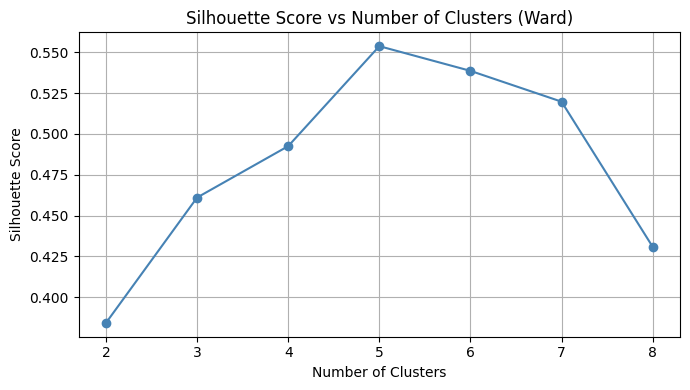

In [59]:
plt.figure(figsize=(7, 4))
plt.plot(k_values, scores_list, marker='o', color='steelblue')
plt.title('Silhouette Score vs Number of Clusters (Ward)')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

#Step 8 - Applying Hierarchical Clustering (Ward, k=5)

### 🎯 Step 8 — Apply Final Clustering (Ward, k=5)

```python
cluster_labels = fcluster(Z, 5, criterion='maxclust')
df['Cluster'] = cluster_labels
```

- **`fcluster(Z, 5, criterion='maxclust')`** — Cuts the pre-built Ward linkage tree to produce exactly 5 integer cluster labels (1 through 5) for all 200 customers
- **`df['Cluster'] = cluster_labels`** — Appends the cluster assignments as a new column in the original DataFrame, enabling downstream analysis

The `value_counts()` output shows how many customers were assigned to each of the 5 clusters — checking for severe imbalance.


In [60]:
cluster_labels = fcluster(Z, 5, criterion='maxclust')
df['Cluster'] = cluster_labels

print("\nCluster value counts:")
print(df['Cluster'].value_counts().sort_index())


Cluster value counts:
Cluster
1    39
2    32
3    21
4    23
5    85
Name: count, dtype: int64


#### Scatter Plot — Final 5 Clusters

```python
colors = ['red', 'blue', 'green', 'orange', 'purple']
for i in range(1, 6):
    mask = df['Cluster'] == i
    plt.scatter(df.loc[mask, 'Annual Income (k$)'],
                df.loc[mask, 'Spending Score (1-100)'],
                c=colors[i-1], label=f'Cluster {i}', s=70, alpha=0.8)
```

- **Boolean mask `df['Cluster'] == i`** — Filters rows belonging to cluster `i`
- Each cluster is plotted separately using a unique color from the `colors` list
- **`s=70`** — Point size; **`alpha=0.8`** — Slight transparency to reveal overlapping points
- **`plt.legend()`** — Adds a color-coded legend identifying each cluster
- Saved as `final_clusters.png`

> 📌 Result: The 5 clusters are visually well-separated in the Income × Spending Score space, confirming the algorithm found the natural groupings identified during EDA.


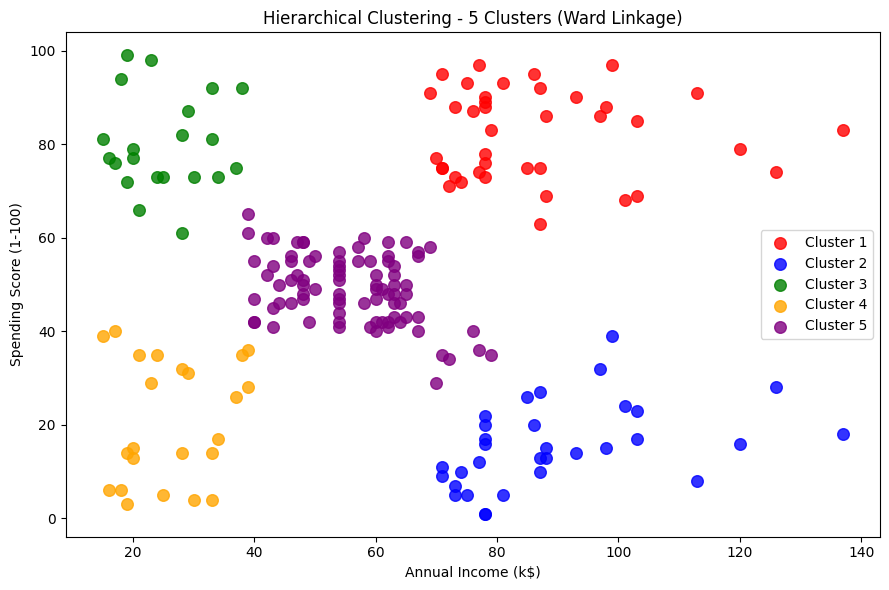

In [61]:
# plotting the clusters
colors = ['red', 'blue', 'green', 'orange', 'purple']

plt.figure(figsize=(9, 6))
for i in range(1, 6):
    mask = df['Cluster'] == i
    plt.scatter(df.loc[mask, 'Annual Income (k$)'],
                df.loc[mask, 'Spending Score (1-100)'],
                c=colors[i-1], label=f'Cluster {i}', s=70, alpha=0.8)

plt.title('Hierarchical Clustering - 5 Clusters (Ward Linkage)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.tight_layout()
plt.savefig('final_clusters.png', dpi=120)
plt.show()

# Step 9 - Cluster Analysis

### 🔬 Step 9 — Cluster Analysis & Profiling

#### Summary Statistics by Cluster

```python
summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
```

- **`groupby('Cluster')`** — Groups the DataFrame by cluster label
- **`.mean().round(1)`** — Computes the average of each feature per cluster, rounded to 1 decimal place
- This produces a **cluster profile table** — the core output for business interpretation

Each row in the summary represents one customer segment with its average Age, Income, and Spending behavior.


In [62]:
print("\nCluster-wise summary:")
summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
print(summary)


Cluster-wise summary:
          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
1        32.7                86.5                    82.1
2        41.0                89.4                    15.6
3        25.3                25.1                    80.0
4        45.2                26.3                    20.9
5        42.5                55.8                    49.1


#### Cluster Sizes

```python
print(df['Cluster'].value_counts().sort_index())
```

Prints the number of customers in each cluster, sorted by cluster label.

- Reveals if any cluster is disproportionately large or small
- Extremely small clusters may indicate outliers rather than meaningful segments
- Well-balanced clusters suggest the algorithm found genuine structure in the data


In [63]:
print("\nCluster sizes:")
print(df['Cluster'].value_counts().sort_index())


Cluster sizes:
Cluster
1    39
2    32
3    21
4    23
5    85
Name: count, dtype: int64


#### Bar Charts — Average Feature Values per Cluster

Creates three side-by-side bar charts showing the mean **Age**, **Annual Income**, and **Spending Score** for each cluster.

```python
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
```

- **`axes[0]`** — Average Age per cluster (blue bars)
- **`axes[1]`** — Average Annual Income per cluster (salmon bars)
- **`axes[2]`** — Average Spending Score per cluster (green bars)

These charts transform the numeric summary table into an intuitive visual format — making cluster differences immediately apparent to non-technical stakeholders.


Text(0, 0.5, 'Spending Score')

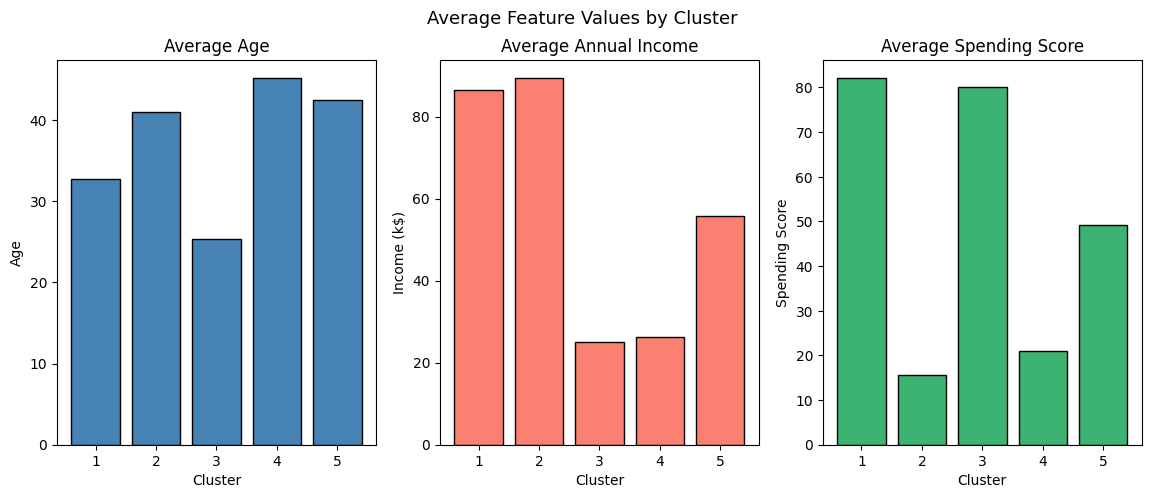

In [64]:
# bar charts for each feature per cluster
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Average Feature Values by Cluster', fontsize=13)

axes[0].bar(summary.index, summary['Age'], color='steelblue', edgecolor='black')
axes[0].set_title('Average Age')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Age')

axes[1].bar(summary.index, summary['Annual Income (k$)'], color='salmon', edgecolor='black')
axes[1].set_title('Average Annual Income')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Income (k$)')

axes[2].bar(summary.index, summary['Spending Score (1-100)'], color='mediumseagreen', edgecolor='black')
axes[2].set_title('Average Spending Score')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Spending Score')

#### Save Cluster Profile Charts

```python
plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=120)
plt.show()
```

- **`tight_layout()`** — Prevents title/label overlaps across the three subplots
- **`savefig('cluster_profiles.png', dpi=120)`** — Saves the visualization to disk at high resolution
- This file can be directly used in business reports or presentations


In [65]:
plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=120)
plt.show()
print("Saved: cluster_profiles.png")

<Figure size 640x480 with 0 Axes>

Saved: cluster_profiles.png


# Step 10 - Save the output

### 💾 Step 10 — Save Output

```python
df.to_csv('mall_customers_with_clusters.csv', index=False)
```

Exports the enriched DataFrame — original 5 columns plus the new `Cluster` column — to a CSV file.

- **`index=False`** — Prevents pandas from writing the row index as an extra column
- The output file `mall_customers_with_clusters.csv` is the **final deliverable** of this project
- This file can be imported into Excel, BI tools (Tableau, Power BI), or CRM systems for business use

The `print("Done!")` confirms successful pipeline completion.


In [66]:
df.to_csv('mall_customers_with_clusters.csv', index=False)
print("\nSaved: mall_customers_with_clusters.csv")

print("\nDone!")


Saved: mall_customers_with_clusters.csv

Done!
